<a href="https://colab.research.google.com/github/ys23-lys/ESAA/blob/main/ESAA_OB_WEEK5_%ED%95%84%EC%82%AC2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2.4 파이토치 코드 맛보기

price(자동차 가격), maint(자동차 유지 비용), doors(자동차 문 개수), persons(수용 인원), lug_capacity(수하물 용량), safety, output(차 상태)

In [3]:
! pip install matplotlib
! install seaborn
! pip install scikit-learn

install: missing destination file operand after 'seaborn'
Try 'install --help' for more information.


In [4]:
! pip install --upgrade matplotlib --use-feature=2020-resolver
! pip install --upgrade seaborn --use-feature=2020-resolver
! pip install --upgrade scikit-learn --use-feature=2020-resolver


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

option --use-feature: invalid choice: '2020-resolver' (choose from 'fast-deps', 'truststore', 'no-binary-enable-wheel-cache')

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

option --use-feature: invalid choice: '2020-resolver' (choose from 'fast-deps', 'truststore', 'no-binary-enable-wheel-cache')

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [opti

In [1]:
# 코드 2-1 필요한 라이브러리 호출
import torch
import torch.nn as nn
import numpy as np # 벡터 및 행렬 연산에서 매우 편리한 기능을 제공하는 파이썬 라이브러리 패키지
import pandas as pd # 데이터 처리를 위해 널리 사용되는 파이썬 라이브러리 패키지
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# 코드 2-2 데이터 호출
dataset=pd.read_csv('/content/drive/MyDrive/Colab/ESAA/car_evaluation.csv')
dataset.head()

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


임베딩(embeding) 처리: 단어를 벡터로 바꾸어 줌.

<Axes: ylabel='count'>

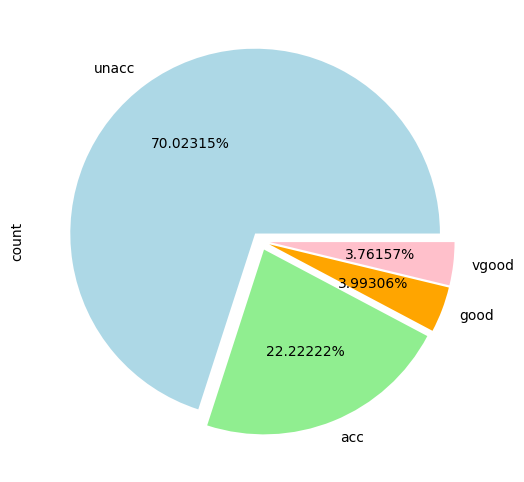

In [7]:
# 코드 2-3 예제 데이터셋 분포
fig_size=plt.rcParams["figure.figsize"]
fig_size[0]=8
fig_size[1]=6
plt.rcParams["figure.figsize"]=fig_size
dataset.output.value_counts().plot(kind='pie',autopct='%0.05f%%',
                                   colors=['lightblue','lightgreen','orange','pink'],explode=(0.05,0.05,0.05,0.05))

In [8]:
# 코드 2-4 데이터를 범주형 타입으로 변환
categorical_columns=['price','maint','doors','persons','lug_capacity','safety']

for category in categorical_columns:
  dataset[category]=dataset[category].astype('category')

price=dataset['price'].cat.codes.values
maint=dataset['maint'].cat.codes.values
doors=dataset['doors'].cat.codes.values
persons=dataset['persons'].cat.codes.values
lug_capacity=dataset['lug_capacity'].cat.codes.values
safety=dataset['safety'].cat.codes.values

categorical_data=np.stack([price,maint,doors,persons,lug_capacity,safety],1)
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

1. 범주형 데이터를 텐서로 변환

**범주형 데이터 -> dataset[category] -> 넘파이 배열(Numpy array) -> 텐서(Tensor)**

cat.codes: 범주형 데이터를 숫자(넘파이 배열)로 변환하기 위해 사용.

넘파이 배열을 통해 텐서를 생성할 수 있음.

2. 두 개 이상의 넘파이 객체를 합침(np.stack 이용)

**np.concatenate**: 선택한 축을 기준으로 두 개의 배열을 연결.

**np.stack**: 배열들을 새로운 축으로 합침. 두 배열의 차원이 동일해야 함.

In [9]:
# 2-5 배열을 텐서로 변환
categorical_data=torch.tensor(categorical_data,dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [10]:
# 코드 2-6 레이블로 사용할 칼럼을 텐서로 변환
outputs=pd.get_dummies(dataset.output)
outputs=outputs.values
outputs=torch.tensor(outputs).flatten()

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


get_dummies: 가변수(dummy variable)로 만들어 주는 함수. -> (0,1)

reval(), reshape(), flatten(): 텐서의 차원을 바꿀 때 사용.

워드 임베딩: 유사한 단어끼리 유사하게 인코딩되도록 표현하는 방법. 높은 차원의 임베딩일수록 단어 간의 세부적인 관계 파악 O. -> **단일 숫자로 변환된 넘파이 배열을 N차원으로 변경하여 사용**
- 모든 범주형 칼럼에 대한 임베딩 크기를 정의: 칼럼의 고유 값 수/2

In [11]:
# 코드 2-7 범주형 칼럼을 N차원으로 변환
categorical_column_sizes=[len(dataset[column].cat.categories) for column in categorical_columns]
categorical_embedding_sizes=[(col_size,min(50,(col_size+1)//2)) for col_size in categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [12]:
# 코드 2-8 데이터셋 분리
total_records=1728
test_records=int(total_records*.2)

categorical_train_data=categorical_data[:total_records - test_records]
categorical_test_data=categorical_data[total_records - test_records:total_records]
train_outputs=outputs[:total_records - test_records]
test_outputs=outputs[total_records - test_records:total_records]

In [13]:
# 코드 2-9 데이터셋 분리 확인
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


In [15]:
# 코드 2-10 모델의 네트워크 생성
class Model(nn.Module):
  def __init__(self,embedding_size,output_size,layers,p=0.4):
    super().__init__()
    self.all_embeddings=nn.ModuleList([nn.Embedding(ni,nf) for ni,
                                       nf in embedding_size])
    self.embedding_dropout=nn.Dropout(p)

    all_layers=[]
    num_categorical_cols=sum((nf for ni,nf in embedding_size))
    input_size=num_categorical_cols

    for i in layers:
      all_layers.append(nn.Linear(input_size,i))
      all_layers.append(nn.ReLU(inplace=True))
      all_layers.append(nn.BatchNorm1d(i))
      all_layers.append(nn.Dropout(p))
      input_size=1

    all_layers.append(nn.Linear(layers[-1],output_size))
    self.layers=nn.Sequential(*all_layers)

  def forward(self,x_categorical):
    embeddings=[]
    for i,e in enumerate(self.all_embeddings):
      embeddings.append(e(x_categorical[:,i]))
      x=torch.cat(embeddings,1)
      x=self.embedding_dropout(x)
      x=self.layers(x)
      return x

1. 클래스 형태로 구현되는 모델은 nn.Module을 상속받음.
2. __init__()은 모델에서 사용될 파라미터와 신경망을 초기화하기 위한 용도로 사용하며, 객체가 생성될 때 자동으로 호출됨. **def __init__(slef,embedding_size,ouput_size,layers,p=0.4)**
- self: 첫 번째 파라미터는 self를 지정해야 함.
- embedding_size: 범주형 칼럼의 임베딩 크기
- output_size: 출력층의 크기
- layers: 모든 계층에 대한 목록
- p: 드롭아웃
3. super().__init__()은 부모 클래스에 접근할 때 사용.
4. 모델의 네트워크 계층을 구축하기 위해 for문을 이용하여 각 계층을 all_layers 목록에 추가.
- Linear(선형 계층), ReLU(활성화 함수), BatchNorm1d(배치 정규화 용도), Dropout(과적합 방지)
5. forward() 함수: 학습 데이터를 입력받아 연산 진행.

In [16]:
# 코드 2-11 Model 클래스의 객체 생성
model=Model(categorical_embedding_sizes,4,[200,100,50],p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=1, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=1, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


In [17]:
# 코드 2-12 모델의 파라미터 정의
loss_function=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [18]:
# 코드 2-13 CPU/GPU 사용 지정
if torch.cuda.is_available():
  device=torch.device('cuda')
else:
  device=torch.device('cpu')

In [20]:
# 코드 2-14 모델 학습
epochs=500
aggregated_losses=[]
train_outputs=train_outputs.to(device=device,dtype=torch.int64)

In [23]:
class Model(nn.Module):
  def __init__(self,embedding_size,output_size,layers,p=0.4):
    super().__init__()
    self.all_embeddings=nn.ModuleList([nn.Embedding(ni,nf) for ni,
                                       nf in embedding_size])
    self.embedding_dropout=nn.Dropout(p)

    all_layers=[]
    num_categorical_cols=sum((nf for ni,nf in embedding_size))
    input_size=num_categorical_cols

    for i in layers:
      all_layers.append(nn.Linear(input_size,i))
      all_layers.append(nn.ReLU(inplace=True))
      all_layers.append(nn.BatchNorm1d(i))
      all_layers.append(nn.Dropout(p))
      input_size=i

    all_layers.append(nn.Linear(layers[-1],output_size))
    self.layers=nn.Sequential(*all_layers)

  def forward(self,x_categorical):
    embeddings=[]
    for i,e in enumerate(self.all_embeddings):
      embeddings.append(e(x_categorical[:,i]))
    x=torch.cat(embeddings,1)
    x=self.embedding_dropout(x)
    x=self.layers(x)
    return x

model=Model(categorical_embedding_sizes,4,[200,100,50],p=0.4)

optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

model.to(device)

epochs=500
aggregated_losses=[]
train_outputs=train_outputs.to(device=device,dtype=torch.int64)
categorical_train_data = categorical_train_data.to(device)

for i in range(epochs):
    i+=1
    y_pred=model(categorical_train_data)
    single_loss=loss_function(y_pred, train_outputs)
    aggregated_losses.append(single_loss)

    if i%25==1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

    optimizer.zero_grad()
    single_loss.backward()
    optimizer.step()

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')

epoch:   1 loss: 1.56978929
epoch:  26 loss: 1.39402127
epoch:  51 loss: 1.30800366
epoch:  76 loss: 1.18233919
epoch: 101 loss: 1.07105219
epoch: 126 loss: 0.93125147
epoch: 151 loss: 0.81176168
epoch: 176 loss: 0.75639027
epoch: 201 loss: 0.69357693
epoch: 226 loss: 0.66455132
epoch: 251 loss: 0.64731956
epoch: 276 loss: 0.63278514
epoch: 301 loss: 0.61276817
epoch: 326 loss: 0.60366130
epoch: 351 loss: 0.59167248
epoch: 376 loss: 0.59574574
epoch: 401 loss: 0.58544642
epoch: 426 loss: 0.57676351
epoch: 451 loss: 0.57902378
epoch: 476 loss: 0.57773483
epoch: 500 loss: 0.5736836195


In [24]:
# 코드 2-15 테스트 데이터셋으로 모델 예측
test_outputs=test_outputs.to(device=device,dtype=torch.int64)
with torch.no_grad():
  y_val=model(categorical_test_data)
  loss=loss_function(y_val,test_outputs)
print(f'Loss:{loss:.8f}')

Loss:0.56129235


In [25]:
# 코드 2-16 모델의 예측 확인
print(y_val[:5])

tensor([[ 4.2368,  2.4441, -6.9484, -7.1083],
        [ 2.0713,  1.3053, -4.0515, -3.8129],
        [ 2.2122,  1.1567, -3.9184, -3.9964],
        [ 1.2401,  0.4534, -2.6412, -2.9283],
        [ 2.4193,  1.5270, -2.4519, -2.7952]])


In [26]:
# 코드 2-17 가장 큰 값을 갖는 인덱스 확인
y_val=np.argmax(y_val,axis=1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


In [28]:
# 코드 2-18 테스트 데이터셋을 이용한 정확도 확인
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(confusion_matrix(test_outputs,y_val))
print(classification_report(test_outputs,y_val)) # Corrected typo: test_outs to test_outputs
print(accuracy_score(test_outputs,y_val))

[[259   0]
 [ 86   0]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       259
           1       0.00      0.00      0.00        86

    accuracy                           0.75       345
   macro avg       0.38      0.50      0.43       345
weighted avg       0.56      0.75      0.64       345

0.7507246376811594


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


딥러닝 분류 모델의 성능 평가 지표: 정확도(accuracy), 재현율(recall), 정밀도(precision), F1-스코어(F1-score)

1. 정확도: 정답을 맞힌 건수/전체 예측 건수

(TP+TN)/(TP+TN+FP+FN)

2. 재현율: 실제 정답이 1일 때 모델도 1로 예측한 비율. 데이터가 1일 확률이 적을 때 사용.

TP/(TP+FN)

3. 정밀도: 모델이 1이라고 예측한 것 중 실제 정답이 1인 비율

TP/(TP+FP)

4. F1-스코어: 정밀도와 재현율의 조화 평균을 이용한 것.

2*(Precison*Recall)/(Precision+Recall)
